## Import Library

In [1]:
# Import Library
import pandas as pd
import re
import emoji
import numpy as np

# Import library untuk EDA
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

# Import Library Data Splitting & Tokenization
# from sklearn.model_selection import train_test_split
# import torch
# from transformers import AutoTokenizer

## Load Data

In [59]:
# Membaca Dataset
dataset1 = pd.read_csv('tokopedia-product-reviews-2019.csv')
dataset2 = pd.read_csv('tokopedia_product_reviews_2025.csv')
dataset3 = pd.read_csv('reviews_output.csv')

# Menampilkan Info
display(dataset1.info())
display(dataset2.info())
display(dataset3.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40607 entries, 0 to 40606
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0    40607 non-null  int64 
 1   text          40607 non-null  object
 2   rating        40607 non-null  int64 
 3   category      40607 non-null  object
 4   product_name  40607 non-null  object
 5   product_id    40607 non-null  int64 
 6   sold          40593 non-null  object
 7   shop_id       40607 non-null  int64 
 8   product_url   40607 non-null  object
dtypes: int64(4), object(5)
memory usage: 2.8+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65543 entries, 0 to 65542
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   review_text       65543 non-null  object
 1   review_date       65543 non-null  object
 2   review_id         65543 non-null  int64 
 3   product_name      65543 non-null  object
 4   product_category  65543 non-null  object
 5   product_variant   26749 non-null  object
 6   product_price     65543 non-null  int64 
 7   product_url       65543 non-null  object
 8   product_id        65543 non-null  int64 
 9   rating            65543 non-null  int64 
 10  sold_count        65543 non-null  int64 
 11  shop_id           65543 non-null  int64 
 12  sentiment_label   65543 non-null  object
dtypes: int64(6), object(7)
memory usage: 6.5+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30119 entries, 0 to 30118
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_name  30119 non-null  object 
 1   rating        30119 non-null  float64
 2   message       30119 non-null  object 
dtypes: float64(1), object(2)
memory usage: 706.0+ KB


None

In [60]:
# Menampilkan Dataset
display(dataset1.head())
display(dataset2.head())
display(dataset3.head())

,Unnamed: 0,text,rating,category,product_name,product_id,sold,shop_id,product_url
0,1,Barang sesuai pesanan dan cepat sampai,5,pertukangan,Staples Dekorasi Staples Kayu + Refill 8mm - S...,418660637,1,1740837,https://www.tokopedia.com/shakaonline87/staple...
1,2,Barang bagus harga murah,5,pertukangan,STAPLE GUN ATS 3 WAY TACKER - STAPLES JOK TEMB...,416032545,11,1477109,https://www.tokopedia.com/juraganperkakas/stap...
2,3,Paket rapi...mantap....cepat....sampe ke tujuan,5,pertukangan,STAPLE GUN ATS 3 WAY TACKER - STAPLES JOK TEMB...,416032545,11,1477109,https://www.tokopedia.com/juraganperkakas/stap...
3,4,ya saya puas dgn barangnya,5,pertukangan,ALAT STAPLES TEMBAK &#40;AIR NAILER GUN&#41; O...,102279869,5,771395,https://www.tokopedia.com/kamarmesin/alat-stap...
4,5,Responya luar biasa b mantap,5,pertukangan,Isi Refill Staples Jok Kulit Motor / Staple Gu...,190679689,787,969999,https://www.tokopedia.com/mitrapersada/isi-ref...


,review_text,review_date,review_id,product_name,product_category,product_variant,product_price,product_url,product_id,rating,sold_count,shop_id,sentiment_label
0,baru sekali ini terima brg dr belanja online d...,2024-12-22,1134256160,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
1,cocok bgt aku sama telur nya. nga Amis menurut...,2025-02-25,1242584634,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
2,Telornya sudah sampai di rumah dengan kemasan ...,2025-07-15,1573444677,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
3,Telor sudah diterima dengan baik dan tidak ada...,2025-07-20,1581728541,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
4,"Alhamdulillah penjual amanah,Telor nya terbaik...",2023-04-24,881041355,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Full Design,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive


,product_name,rating,message
0,[COD] Headset Bluetooth Nirkabel TWS CID17 den...,3.0,Kejernihan lensa: Lumayan jernih\nKualitas pen...
1,[COD] Headset Bluetooth Nirkabel TWS CID17 den...,3.0,"saya beli 3, dan 1 tidak berfungsi dengan baik..."
2,[COD] Headset Bluetooth Nirkabel TWS CID17 den...,3.0,"Ka ko punyaku kaya gini, terus ganyala si yg k..."
3,[COD] Headset Bluetooth Nirkabel TWS CID17 den...,2.0,Alhamdulillah paketnya sudah datang dengan sel...
4,[COD] Headset Bluetooth Nirkabel TWS CID17 den...,1.0,"Batre Kosong, Barang sesuai Tidak Normal suara..."


In [61]:
# Mengambil Kolom Ulasan dan Rating
dataset1 = dataset1[['text', 'rating']]
dataset2 = dataset2[['review_text', 'rating']]
dataset3 = dataset3[['message', 'rating']]

# Mengubah Nama Kolom
dataset1.columns = ['ulasan', 'rating']
dataset2.columns = ['ulasan', 'rating']
dataset3.columns = ['ulasan', 'rating']

# Menggabungkan Dataset
dataset = pd.concat([dataset1, dataset2, dataset3], ignore_index=True)

## Preprocessing

In [62]:
# Menampilkan Dataset
display(dataset.head())

# Menampilkan Info
dataset.info()

,ulasan,rating
0,Barang sesuai pesanan dan cepat sampai,5.0
1,Barang bagus harga murah,5.0
2,Paket rapi...mantap....cepat....sampe ke tujuan,5.0
3,ya saya puas dgn barangnya,5.0
4,Responya luar biasa b mantap,5.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136269 entries, 0 to 136268
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ulasan  136269 non-null  object 
 1   rating  136269 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.1+ MB


In [63]:
# Melihat Informasi Statistik Ulasan
display(pd.DataFrame(dataset['ulasan'].str.len().describe().round(0)))
dataset.describe().round(0)

,ulasan
count,136269.0
mean,71.0
std,128.0
min,1.0
25%,34.0
50%,53.0
75%,85.0
max,32857.0


,rating
count,136269.0
mean,4.0
std,1.0
min,1.0
25%,3.0
50%,5.0
75%,5.0
max,5.0


In [64]:
# Mengecek Isi Dataset
print(f'Jumlah Duplikat : {dataset.duplicated().sum()}')
print(f'Jumlah Null     : \n{dataset.isna().sum()}')
print(f"Jumlah Data Kosong : {(dataset['ulasan'].str.strip() == ' ').sum()}")

# Menghapus Data Duplikat
dataset = dataset.drop_duplicates()
print(f'Jumlah Duplikat : {dataset.duplicated().sum()}')
print(f'Jumlah Dataset  : {len(dataset)}')

Jumlah Duplikat : 11349
Jumlah Null     : 
ulasan    0
rating    0
dtype: int64
Jumlah Data Kosong : 0


In [65]:
# Menampilkan Isi Yang Jumlah Karakternya Max
display(
    pd.DataFrame({
        'ulasan': dataset['ulasan'],
        'panjang_karakter': dataset['ulasan'].str.len()
    })
    .sort_values('panjang_karakter', ascending=False)
    .head(20)
)

,ulasan,panjang_karakter
87139,TOP MANTAP IS THE BEST. . . .TOP MANTAP IS THE...,32857
105534,Jan mantap bakul e satset CO hari ini langsung...,14517
96990,Bismillahirohmanirohim assalamualaikum warrohm...,6772
103659,Bismillahirohmanirohim assalamualaikum warrohm...,6772
91465,Bismillahirohmanirohim assalamualaikum warrohm...,6772
99859,Bismillahirohmanirohim assalamualaikum warrohm...,6772
91466,Bismillahirohmanirohim assalamualaikum warrohm...,6772
101223,Bismillahirohmanirohim assalamualaikum warrohm...,6772
91464,Bismillahirohmanirohim assalamualaikum warrohm...,6772
98487,ͮͮ ☛⧼🥶⃟F͙I͙R͙ͮE͙ͥF͙ͬA͙ͧL͙ᷤL͙⧽͜🥵🔥 😡҈҈҈҉҉҉҉҈҈҈҈҈...,4077


In [66]:
# Melihat Ulasan Yang Hanya Berisi Simbol
simbol = dataset['ulasan'].apply(lambda x: len(str(x).strip('.!?,-_*/;& ')) == 0)

print("Jumlah simbol saja:", simbol.sum())

df_simbol = dataset[simbol][['ulasan']]
df_simbol

Jumlah simbol saja: 144


,ulasan
586,......................
775,......................
1351,..................................
1682,!!!!!!!!!!!!!!!!!!!!!!!!!!!!
1924,.................................................
...,...
131615,.
131919,.
132153,-
132841,**********************************************...


In [67]:
# Fungsi Preprocessing Teks
def preprocessing_teks(teks) :
    # Formatting Teks
    teks = teks.lower()

    # Hapus URL
    teks = re.sub(r'https?://\S+|www\.\S+', '', teks)
    teks = re.sub(r'\b\S+\.(com|co\.id|id|net|org|io|app|xyz)(\S*)', '', teks)

    # Menghapus Hastag dan Mention
    teks = re.sub(r'[@#]\S+', '', teks)

    # Menghapus Karakter Berulang
    teks = re.sub(r'(.)\1{2,}', r'\1', str(teks))

    # Merubah Icon Emoji Menjadi Teks
    teks = emoji.demojize(teks, delimiters=(" ", " "))
    teks = teks.replace("_", " ")

    # Mengubah semua tanda baca dan simbol selain huruf/angka menjadi spasi
    teks = re.sub(r'[^\w\s]', ' ', teks)

    # Menghapus Spasi Berlebih
    teks = re.sub(r'\s+', ' ', teks).strip()

    # Mengatasi Ulasan Yang Cuman Simbol
    if len(teks) == 0:
        return ""

    return teks

In [68]:
# Membaca Dataset Kata Slang
data_slang = pd.read_csv('slang.csv')
data_slang = data_slang[['slang', 'formal']]

# Ubah Menjadi Dictionary
dict_slang = dict(
    zip(data_slang['slang'], data_slang['formal'])
)

# Fungsi Normalisasi Kata
def normalisasi_kata(teks):
    kata = teks.split()

    normalisasi = [
        dict_slang.get(word, word)
        for word in kata
    ]

    return " ".join(normalisasi)

In [69]:
# Menerapkan Fungsi Ke Dataset
dataset['ulasan'] = (
    dataset['ulasan']
    .apply(preprocessing_teks)
    .apply(normalisasi_kata)
)

## Cek Hasil Preprocessing

In [70]:
# Fungsi Validasi Hasil Processing
def cek_hasil_preprocessing(dataset, kolom='ulasan'):

    print("=" * 30)
    print("HASIL VALIDASI PREPROCESSING")
    print("=" * 30)

    hasil = {
        "URL":
            dataset[kolom].str.contains(
                r'https?://|www\.',
                regex=True,
                na=False
            ).sum(),

        "Mention/Hashtag":
            dataset[kolom].str.contains(
                r'@\w+|#\w+',
                regex=True,
                na=False
            ).sum(),

        "Emoji":
            dataset[kolom].apply(
                lambda x: len(emoji.emoji_list(str(x))) > 0
            ).sum(),

        "Karakter Berulang":
            dataset[kolom].apply(
                lambda x: bool(re.search(r'(.)\1{2,}', str(x)))
            ).sum(),

        "Karakter Aneh":
            dataset[kolom].str.contains(
                r'[^\w\s.,?!*/&-]',
                regex=True,
                na=False
            ).sum(),

        "Spasi Berlebih":
            dataset[kolom].str.contains(
                r'\s{2,}',
                regex=True,
                na=False
            ).sum(),

        "Review Kosong":
            (
                dataset[kolom]
                .fillna('')
                .str.strip() == ''
            ).sum()
    }

    for item, jumlah in hasil.items():
        print(f"{item:<20} : {jumlah}")

    print(f'\nJumlah Dataset       : {len(dataset)}')

In [71]:
cek_hasil_preprocessing(dataset)

HASIL VALIDASI PREPROCESSING
URL                  : 0
Mention/Hashtag      : 0
Emoji                : 0
Karakter Berulang    : 0
Karakter Aneh        : 0
Spasi Berlebih       : 0
Review Kosong        : 163

Jumlah Dataset       : 136269


In [78]:
# Menghapus Kata Yang Panjang dan Berulang
dataset = dataset[dataset['ulasan'].str.len() < 1400]

display(
    pd.DataFrame({
        'ulasan': dataset['ulasan'],
        'panjang_karakter': dataset['ulasan'].str.len()
    })
    .sort_values('panjang_karakter', ascending=False)
    .head(10)
)

,ulasan,panjang_karakter
66423,awalnya gue beli cuma karena lagi suntuk lagi ...,1355
67714,produk bagus well recommended model barang sam...,1346
67325,lem epoxy non sag lem serbaguna walau ada logo...,1302
62197,seller agak lain ini driver gosend seolah2 deh...,1266
99557,kecewa angry face pesan lengan panjang dan len...,1261
43820,barang selamat sampai tujuan cuma ada hal yang...,1244
48416,yuk buat teman teman yang ingin mencari pengga...,1243
29023,inilah review non bias dari saya well im impre...,1242
113737,mau tanya-tanya produk sebelum membeli agak ke...,1239
50837,saya beli cap lang sitronela karena katanya bi...,1231


In [79]:
# Mengecek Isi Dataset
print(f'Jumlah Duplikat : {dataset.duplicated().sum()}')
print(f'Jumlah Null     : \n{dataset.isna().sum()}')
print(f"Jumlah Data Kosong : {(dataset['ulasan'].str.strip() == ' ').sum()}")

# Menghapus Data Duplikat
dataset = dataset.drop_duplicates()
print(f'Jumlah Duplikat : {dataset.duplicated().sum()}')
print(f'Jumlah Dataset  : {len(dataset)}')

Jumlah Duplikat : 0
Jumlah Dataset  : 117884


In [80]:
cek_hasil_preprocessing(dataset)

HASIL VALIDASI PREPROCESSING
URL                  : 0
Mention/Hashtag      : 0
Emoji                : 0
Karakter Berulang    : 0
Karakter Aneh        : 0
Spasi Berlebih       : 0
Review Kosong        : 0

Jumlah Dataset       : 117884


In [75]:
# Melihat Informasi Statistik Ulasan
display(pd.DataFrame(dataset['ulasan'].str.len().describe().round(0)))
dataset.describe().round(0)

,ulasan
count,117888.0
mean,78.0
std,68.0
min,1.0
25%,38.0
50%,58.0
75%,94.0
max,1493.0


,rating
count,117888.0
mean,4.0
std,1.0
min,1.0
25%,3.0
50%,5.0
75%,5.0
max,5.0


In [77]:
# Menampilkan Dataset
dataset.head(10)

,ulasan,rating
0,barang sesuai pesanan dan cepat sampai,5.0
1,barang bagus harga murah,5.0
2,paket rapi mantap cepat sampai ke tujuan,5.0
3,ya saya puas dengan barangnya,5.0
4,responya luar biasa b mantap,5.0
5,seller top pengiriman cepat barang oke,5.0
6,pengiriman cepat seller top,5.0
7,produk sesuai dengan spec di web dan respon se...,5.0
8,respon super cepat pengiriman cepat barang bag...,5.0
9,barang mantap pelayanan cepat,5.0


## Labeling

In [18]:
# Load Kamus
lexicon_positive = pd.read_csv(
    'lexicon_positive.tsv',
    sep='\t',
    header=0
)

lexicon_positive.columns = [
    'word',
    'weight'
]

lexicon_positive.head(10)

,word,weight
0,hai,3
1,merekam,2
2,ekstensif,3
3,paripurna,1
4,detail,2
5,pernik,3
6,belas,2
7,welas,4
8,kabung,1
9,rahayu,4


In [19]:
lexicon_negative = pd.read_csv(
    'lexicon_negative.tsv',
    sep='\t',
    header=0
)

lexicon_negative.columns = [
    'word',
    'weight'
]

lexicon_negative.head(10)

,word,weight
0,putus tali gantung,-2
1,gelebah,-2
2,gobar hati,-2
3,tersentuh (perasaan),-1
4,isak,-5
5,larat hati,-3
6,nelangsa,-3
7,remuk redam,-5
8,tidak segan,-2
9,gemar,-1


In [20]:
# Membuat Dictionary Positif
positive_dict = {}
for index, row in lexicon_positive.iterrows():
    positive_dict[row['word']] = int(row['weight'])

In [21]:
# Membuat Dictionary Negatif
negative_dict = {}
for index, row in lexicon_negative.iterrows():
    negative_dict[row['word']] = int(row['weight'])

In [22]:
# Membuat Fungsi Scoring
def sentiment_score(text):

    words = text.split()

    score = 0

    for word in words:

        if word in positive_dict:
            score += positive_dict[word]

        elif word in negative_dict:
            score += negative_dict[word]

    return score

In [23]:
dataset.columns

Index(['ulasan', 'rating'], dtype='object')

In [24]:
# 1. Menambahkan istilah khusus  ke kamus positif
kata_ecommerce_positif = {
    'aman': 4,
    'packing': 3,
    'deskripsi': 2,
    'fast': 3,
    'thumbs': 3,
    'ori': 4,
    'original': 4,
    'berfungsi': 3,
    'normal': 2,
    'lancar': 3
}

# Update dictionary positif
positive_dict.update(kata_ecommerce_positif)


# 2. Daftar kata yang salah masuk di kamus negatif
kata_salah_negatif = [
    'cepat', 'bagus', 'sudah', 'pengiriman', 'yang',
    'kasih', 'sampai', 'baik', 'rapi', 'deskripsi',
    'sangat', 'saya', 'ada', 'enak'
]

# Hapus kata-kata tersebut dari kamus negatif
for kata in kata_salah_negatif:
    if kata in negative_dict:
        del negative_dict[kata]

print("Kamus berhasil di-update dan dibersihkan!")

Kamus berhasil di-update dan dibersihkan!


In [25]:
dataset['clean_text'] = dataset['ulasan'].apply(
    preprocessing_teks
)

dataset[['ulasan','clean_text']].head()

,ulasan,clean_text
0,barang sesuai pesanan dan cepat sampai,barang sesuai pesanan dan cepat sampai
1,barang bagus harga murah,barang bagus harga murah
2,paket rapi mantap cepat sampai ke tujuan,paket rapi mantap cepat sampai ke tujuan
3,ya saya puas dengan barangnya,ya saya puas dengan barangnya
4,responya luar biasa b mantap,responya luar biasa b mantap


In [26]:
# Hitung Scor
dataset['score_sentimen'] = dataset['clean_text'].apply(
    sentiment_score
)
dataset[['clean_text','score_sentimen']].head(25)

,clean_text,score_sentimen
0,barang sesuai pesanan dan cepat sampai,8
1,barang bagus harga murah,8
2,paket rapi mantap cepat sampai ke tujuan,17
3,ya saya puas dengan barangnya,7
4,responya luar biasa b mantap,7
5,seller top pengiriman cepat barang oke,10
6,pengiriman cepat seller top,8
7,produk sesuai dengan spec di web dan respon se...,14
8,respon super cepat pengiriman cepat barang bag...,18
9,barang mantap pelayanan cepat,11


In [27]:
# Membuat Label Sentimen
def labeling(score):

    if score > 0:
        return 'Positif'

    elif score < 0:
        return 'Negatif'

    else:
        return 'Netral'

In [28]:
dataset['label'] = dataset['score_sentimen'].apply(
    labeling
)

In [29]:
# Cek Hasil Labeling
dataset[
    ['clean_text',
     'score_sentimen',
     'label']
].head(25)

,clean_text,score_sentimen,label
0,barang sesuai pesanan dan cepat sampai,8,Positif
1,barang bagus harga murah,8,Positif
2,paket rapi mantap cepat sampai ke tujuan,17,Positif
3,ya saya puas dengan barangnya,7,Positif
4,responya luar biasa b mantap,7,Positif
5,seller top pengiriman cepat barang oke,10,Positif
6,pengiriman cepat seller top,8,Positif
7,produk sesuai dengan spec di web dan respon se...,14,Positif
8,respon super cepat pengiriman cepat barang bag...,18,Positif
9,barang mantap pelayanan cepat,11,Positif


## Exploratory Data Analysis

In [30]:
# Distribusi Label
dataset['label'].value_counts()

,count
label,
Positif,85879
Negatif,6019
Netral,3532


In [31]:
# Cek Missing Value
dataset.isnull().sum()

,0
ulasan,0
rating,0
clean_text,0
score_sentimen,0
label,0


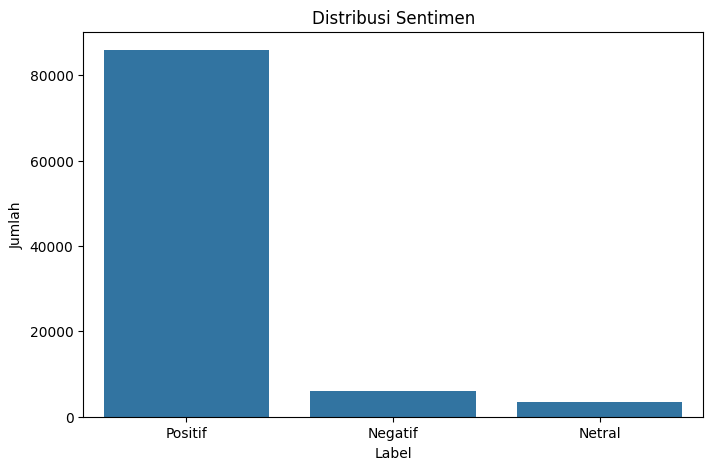

In [32]:
# Visualisasi Distribusi Sentimen

plt.figure(figsize=(8,5))

sns.countplot(
    x='label',
    data=dataset
)

plt.title('Distribusi Sentimen')
plt.xlabel('Label')
plt.ylabel('Jumlah')

plt.show()

In [33]:
# EDA Panjang Ulasan
dataset['jumlah_kata'] = (
    dataset['clean_text']
    .apply(lambda x: len(str(x).split()))
)

In [34]:
dataset['jumlah_kata'].describe()

,jumlah_kata
count,95430.000000
mean,11.325369
std,11.038182
min,1.000000
25%,5.000000
50%,8.000000
75%,14.000000
max,447.000000


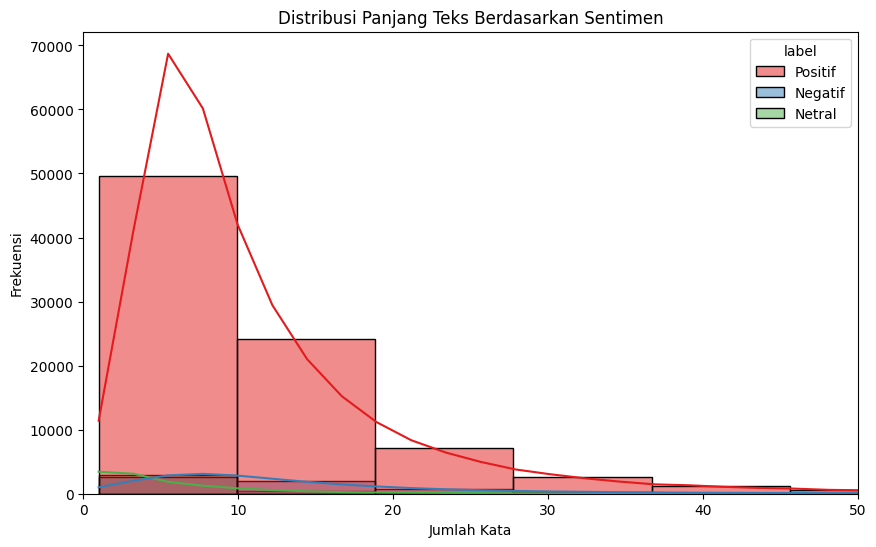

In [35]:
# Tambahkan kolom jumlah kata
dataset['jumlah_kata'] = dataset['clean_text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(data=dataset, x='jumlah_kata', hue='label', kde=True, bins=50, palette='Set1')
plt.title('Distribusi Panjang Teks Berdasarkan Sentimen')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.xlim(0, 50)
plt.show()

In [36]:
# World Cloud Positif
text_positif = " ".join(
    dataset[
        dataset['label']=='Positif'
    ]['clean_text']
)

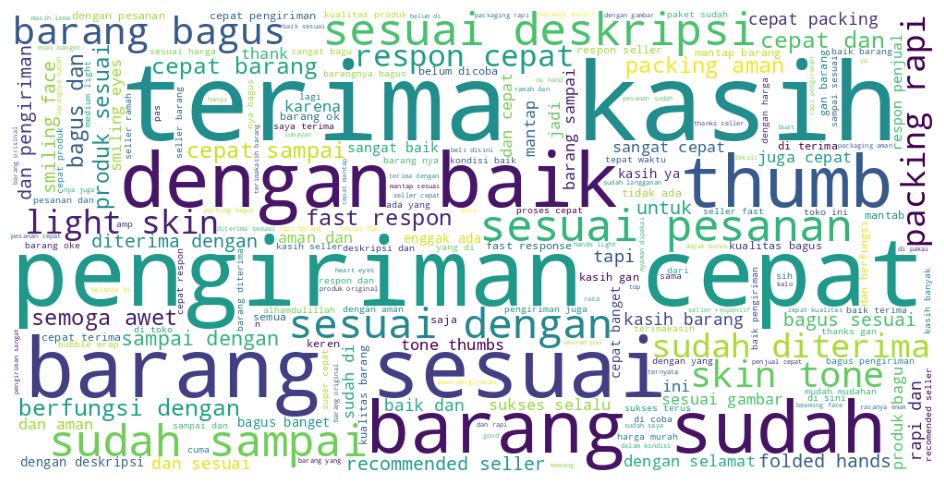

In [37]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text_positif)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.show()

In [38]:
# World Cloud Negatif
text_negatif = " ".join(
    dataset[
        dataset['label']=='Negatif'
    ]['clean_text']
)

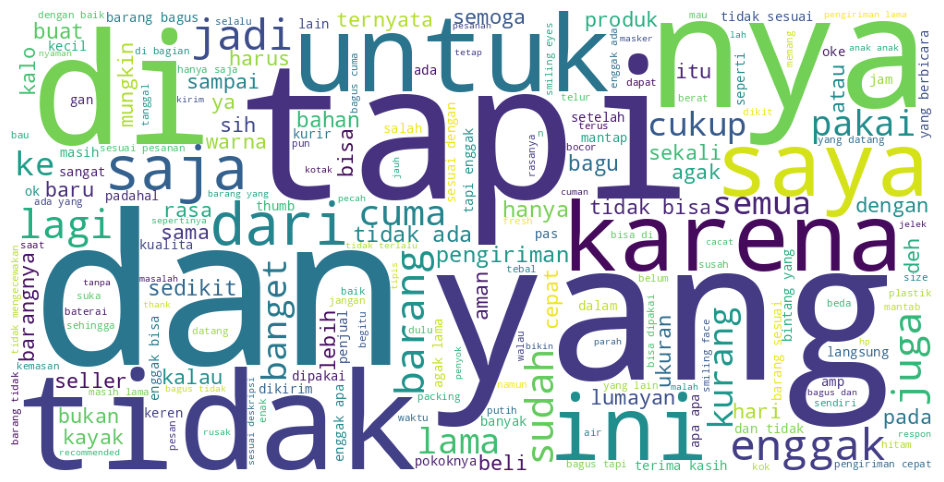

In [39]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text_negatif)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.show()

In [40]:
# Wourld Cloud Netral
text_netral = " ".join(
    dataset[
        dataset['label'] == 'Netral'
    ]['clean_text']
)

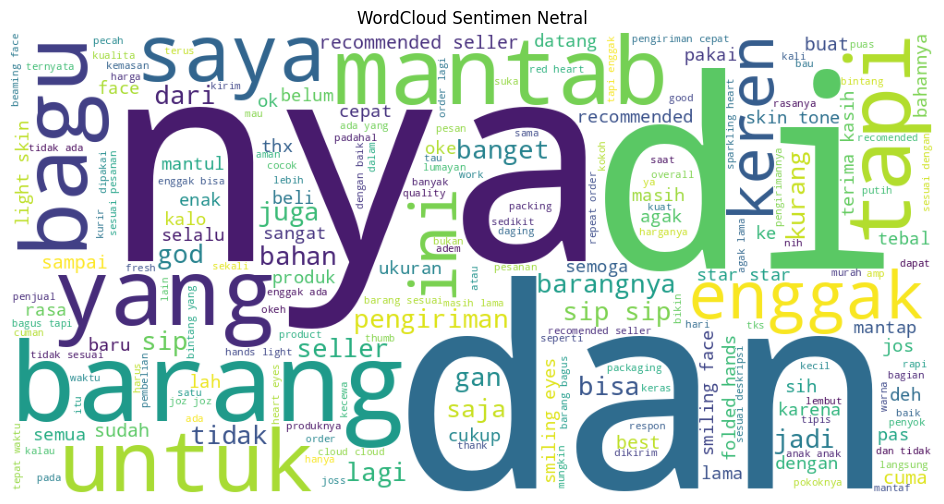

In [41]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text_netral)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.title('WordCloud Sentimen Netral')

plt.show()

/tmp/ipykernel_5178/3698224506.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Freq', y='Ngram', data=top_df, palette='Blues_d')


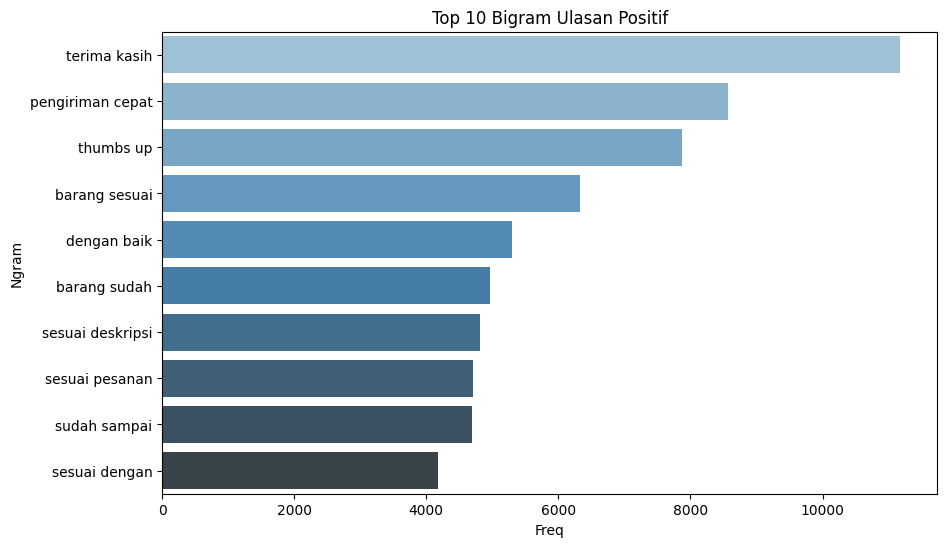

In [42]:
# Analisis Bigram
def plot_top_ngrams(corpus, n=None, ngram_range=(2,2), title="Top 10 Bigrams"):
    vec = CountVectorizer(ngram_range=ngram_range).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)

    top_df = pd.DataFrame(words_freq[:n], columns=['Ngram', 'Freq'])

    plt.figure(figsize=(10,6))
    sns.barplot(x='Freq', y='Ngram', data=top_df, palette='Blues_d')
    plt.title(title)
    plt.show()

# Panggil fungsi untuk Bigram Positif
plot_top_ngrams(dataset[dataset['label'] == 'Positif']['clean_text'], n=10, ngram_range=(2,2), title='Top 10 Bigram Ulasan Positif')

/tmp/ipykernel_5178/17678576.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Freq', y='Ngram', data=top_df, palette='Blues_d')


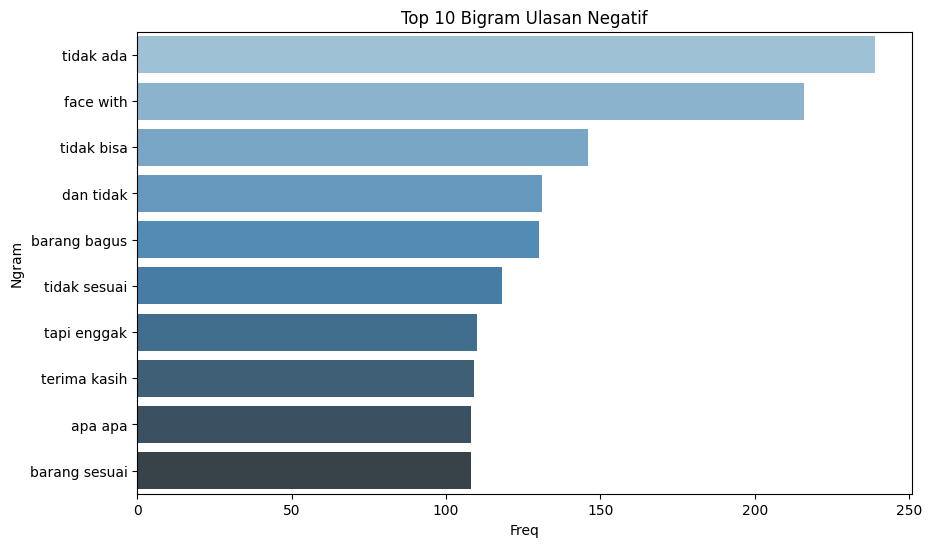

In [43]:
# Analisis Bigram
def plot_top_ngrams(corpus, n=None, ngram_range=(2,2), title="Top 10 Bigrams"):
    vec = CountVectorizer(ngram_range=ngram_range).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)

    top_df = pd.DataFrame(words_freq[:n], columns=['Ngram', 'Freq'])

    plt.figure(figsize=(10,6))
    sns.barplot(x='Freq', y='Ngram', data=top_df, palette='Blues_d')
    plt.title(title)
    plt.show()

# Panggil fungsi untuk Bigram Negatif
plot_top_ngrams(dataset[dataset['label'] == 'Negatif']['clean_text'], n=10, ngram_range=(2,2), title='Top 10 Bigram Ulasan Negatif')

In [44]:
# Top 20 Kata Positif
kata_pos = " ".join(
    dataset[
        dataset['label']=='Positif'
    ]['clean_text']
).split()

counter_pos = Counter(kata_pos)

top20_pos = counter_pos.most_common(20)

pd.DataFrame(
    top20_pos,
    columns=['Kata','Frekuensi']
)

,Kata,Frekuensi
0,barang,27205
1,dan,27083
2,cepat,25990
3,sesuai,24180
4,bagus,20005
5,dengan,15843
6,sudah,15664
7,pengiriman,14137
8,terima,13062
9,kasih,11961


In [45]:
# Top 20 Kata Negatif
kata_neg = " ".join(
    dataset[
        dataset['label']=='Negatif'
    ]['clean_text']
).split()

counter_neg = Counter(kata_neg)

top20_neg = counter_neg.most_common(20)

pd.DataFrame(
    top20_neg,
    columns=['Kata','Frekuensi']
)

,Kata,Frekuensi
0,tidak,1852
1,yang,1761
2,di,1401
3,dan,1363
4,enggak,1192
5,tapi,1164
6,bagus,1107
7,barang,1076
8,nya,1020
9,saya,823


In [46]:
pd.crosstab(
    dataset['rating'],
    dataset['label']
)

label,Negatif,Netral,Positif
rating,,,
1,456,75,544
2,261,50,318
3,636,195,1737
4,1054,407,7991
5,3612,2805,75289


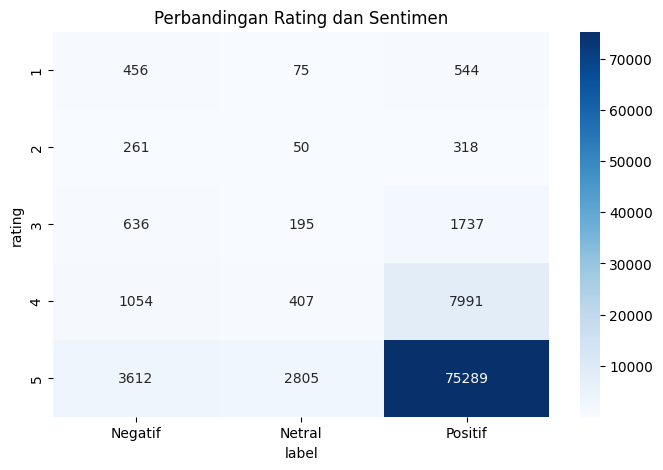

In [47]:
plt.figure(figsize=(8,5))

sns.heatmap(
    pd.crosstab(
        dataset['rating'],
        dataset['label']
    ),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'Perbandingan Rating dan Sentimen'
)

plt.show()

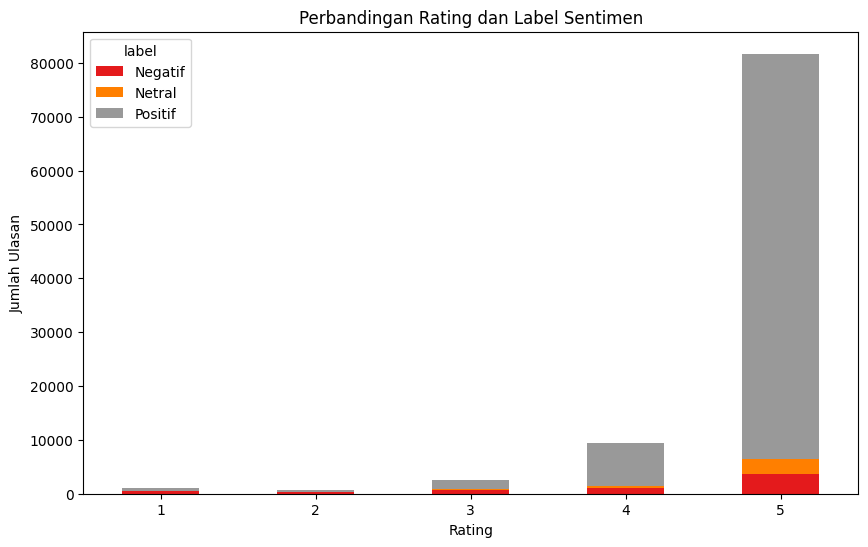

In [48]:
crosstab_data = pd.crosstab(dataset['rating'], dataset['label'])
crosstab_data.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set1')
plt.title('Perbandingan Rating dan Label Sentimen')
plt.xlabel('Rating')
plt.ylabel('Jumlah Ulasan')
plt.xticks(rotation=0)
plt.show()

## Data Splitting

In [49]:
dataset.head()

,ulasan,rating,clean_text,score_sentimen,label,jumlah_kata
0,barang sesuai pesanan dan cepat sampai,5,barang sesuai pesanan dan cepat sampai,8,Positif,6
1,barang bagus harga murah,5,barang bagus harga murah,8,Positif,4
2,paket rapi mantap cepat sampai ke tujuan,5,paket rapi mantap cepat sampai ke tujuan,17,Positif,7
3,ya saya puas dengan barangnya,5,ya saya puas dengan barangnya,7,Positif,5
4,responya luar biasa b mantap,5,responya luar biasa b mantap,7,Positif,5


In [50]:
# Encoding Label Sentiment
label_mapping = {
    'Negatif' : 0,
    'Netral' : 1,
    'Positif' : 2
}

dataset['label_id'] = dataset['label'].map(label_mapping)

# Membuat DataFrame Baru
df_dataset = dataset[['clean_text', 'rating', 'label', 'label_id']].rename(
    columns={'clean_text': 'ulasan'}
)

df_dataset.head()

,ulasan,rating,label,label_id
0,barang sesuai pesanan dan cepat sampai,5,Positif,2
1,barang bagus harga murah,5,Positif,2
2,paket rapi mantap cepat sampai ke tujuan,5,Positif,2
3,ya saya puas dengan barangnya,5,Positif,2
4,responya luar biasa b mantap,5,Positif,2


In [51]:
# Data Splitting
X = df_dataset['ulasan']
y = df_dataset['label_id']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

# Cek Jumlah Data Latihan dan Data Test
print(f'Jumlah Data Latih : {len(X_train)}')
print(f'Jumlah Data Test  : {len(X_test)}')

Jumlah Data Latih : 76344
Jumlah Data Test  : 19086


## Tokenization

In [65]:
# Load Model Tokenizer Indobert
model_name = "indobenchmark/indobert-base-p2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Tokenization Data Latihan
train_tokenized = tokenizer (
    X_train.tolist(),
    truncation=True,
    padding='max_length',
    max_length=128,
    return_tensors='pt'
)

# Tokenization Data Test
test_tokenized = tokenizer (
    X_test.tolist(),
    truncation=True,
    padding='max_length',
    max_length=128,
    return_tensors='pt'
)


In [64]:
# Cek Hasil Tokenization
print("Teks Asli:")
print(X_train.iloc[0])

print("\nToken:")
print(tokenizer.tokenize(X_train.iloc[0]))

print("\nInput IDs:")
print(train_tokenized['input_ids'][0][:20])

print("\nAttention Mask:")
print(train_tokenized['attention_mask'][0][:20])

Teks Asli:
barang sesuai deskripsi diterima dengan baik dan tepat waktu

Token:
['barang', 'sesuai', 'deskripsi', 'diterima', 'dengan', 'baik', 'dan', 'tepat', 'waktu']

Input IDs:
tensor([   2,  963,  786, 9034, 2993,   79,  342,   41, 1234,  486,    3,    0,
           0,    0,    0,    0,    0,    0,    0,    0])

Attention Mask:
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0])
